# Barcelona Noise Prediction: OSM Land Use Feature Engineering
This notebook processes the OSM land use geopackage to extract percentages of commercial, residential, industrial, green, and other areas within 50m and 100m buffers of our street network.

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Loading spatial data...")
# Fixing the path: since the notebook is now in notebooks/osm/, we need to go up two levels to reach layers/
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
noise_streets['fid'] = noise_streets.index # Assign explicitly a numeric FID
print("Streets CRS:", noise_streets.crs)
print("Number of street segments:", len(noise_streets))

osm_landuse = gpd.read_file("../../layers/bcn_gis_osm_landuse.gpkg")
print("OSM Landuse CRS:", osm_landuse.crs)
print("Number of land use polygons:", len(osm_landuse))

# Ensure CRSs match
if osm_landuse.crs != noise_streets.crs:
    print("Aligning CRS...")
    osm_landuse = osm_landuse.to_crs(noise_streets.crs)

display(osm_landuse.head(2))

Loading spatial data...


DataSourceError: ../../layers/BCN_noise_streets.gpkg: No such file or directory

## Categorize OSM Land Use
We map the different OSM categories from `fclass` to our standard Machine Learning buckets.

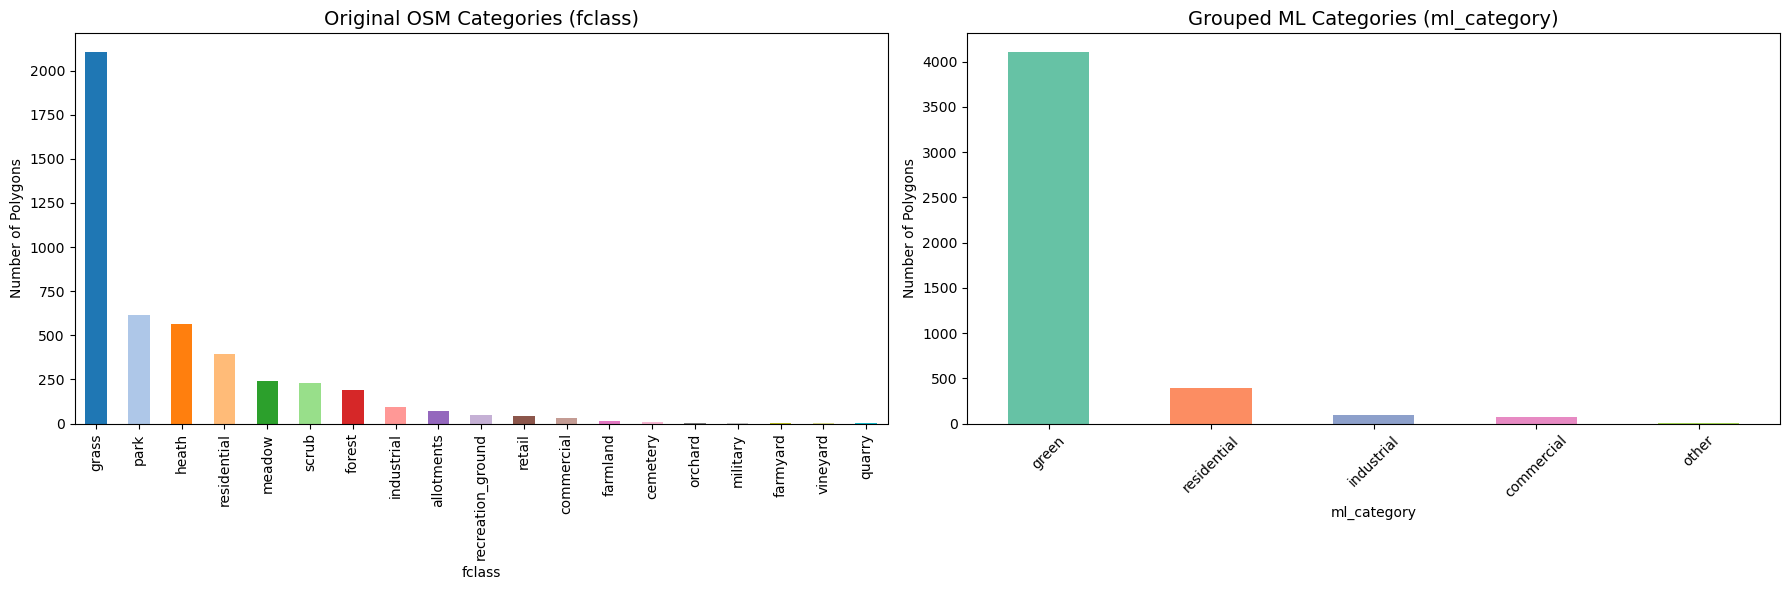

In [2]:
osm_to_ml_buckets = {
    'residential': 'residential',
    'commercial': 'commercial',
    'retail': 'commercial',
    'industrial': 'industrial',
    'quarry': 'industrial',
    'allotments': 'green',
    'cemetery': 'green',
    'farmland': 'green',
    'farmyard': 'green',
    'forest': 'green',
    'grass': 'green',
    'heath': 'green',
    'meadow': 'green',
    'orchard': 'green',
    'park': 'green',
    'recreation_ground': 'green',
    'scrub': 'green',
    'vineyard': 'green',
    'military': 'other'
}

# Apply mapping to the 'fclass' column
osm_landuse['ml_category'] = osm_landuse['fclass'].map(osm_to_ml_buckets).fillna('other')

# Viz the bucketing
fclass_counts = osm_landuse['fclass'].value_counts()
ml_counts = osm_landuse['ml_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fclass_counts.plot(kind='bar', ax=axes[0], color=plt.cm.tab20.colors[:len(fclass_counts)])
axes[0].set_title("Original OSM Categories (fclass)", fontsize=14)
axes[0].set_ylabel("Number of Polygons")
axes[0].tick_params(axis='x', rotation=90)

ml_counts.plot(kind='bar', ax=axes[1], color=plt.cm.Set2.colors[:len(ml_counts)])
axes[1].set_title("Grouped ML Categories (ml_category)", fontsize=14)
axes[1].set_ylabel("Number of Polygons")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Define the Buffer and Math Function
Same pipeline: apply a buffer to streets, find intersections with land use polygons, and evaluate percentages.

In [ ]:
def calculate_osm_landuse_pct(streets_gdf, landuse_gdf, buffer_size):
    print(f"Processing {buffer_size}m buffers...")
    
    buffered = streets_gdf.copy()
    buffered['geometry'] = buffered.geometry.buffer(buffer_size)
    buffered['buffer_area'] = buffered.geometry.area
    
    # Intersect with landuse
    intersection = gpd.overlay(buffered, landuse_gdf, how='intersection')
    intersection['intersected_area'] = intersection.geometry.area
    
    grouped = intersection.groupby(['fid', 'TRAM', 'ml_category'])['intersected_area'].sum().reset_index()
    grouped = grouped.merge(buffered[['fid', 'TRAM', 'buffer_area']], on=['fid', 'TRAM'])
    grouped['pct'] = (grouped['intersected_area'] / grouped['buffer_area']) * 100
    
    # Use both fid and TRAM as index
    features = grouped.pivot(index=['fid', 'TRAM'], columns='ml_category', values='pct').fillna(0)
    
    # Make sure we don't have clashing names with the Usos_sol features, add osm_ prefix
    features.columns = [f"osm_{col}_pct_{buffer_size}m" for col in features.columns]
    
    return features.reset_index()

## Execute Extract

In [4]:
features_50m = calculate_osm_landuse_pct(noise_streets, osm_landuse, 50)
features_100m = calculate_osm_landuse_pct(noise_streets, osm_landuse, 100)

display(features_50m.head(3))

Processing 50m buffers...
Processing 100m buffers...


,TRAM,osm_commercial_pct_50m,osm_green_pct_50m,osm_industrial_pct_50m,osm_other_pct_50m,osm_residential_pct_50m
0,LRD0003,0.0,17.474237,0.0,0.0,0.0
1,LRD0004,0.0,3.649303,0.0,0.0,0.0
2,LRD0005,0.0,18.494728,0.0,0.0,0.0


## Merge and Export

In [ ]:
dataset = pd.DataFrame({
    "fid": noise_streets['fid'],
    "street_id": noise_streets['TRAM']
})

# Attach the 50m and 100m features
dataset = dataset.merge(features_50m, left_on=['fid', 'street_id'], right_on=['fid', 'TRAM'], how='left').drop(columns=['TRAM'], errors='ignore')
dataset = dataset.merge(features_100m, left_on=['fid', 'street_id'], right_on=['fid', 'TRAM'], how='left').drop(columns=['TRAM'], errors='ignore')

dataset = dataset.fillna(0)
display(dataset.head(5))

# Also fix the export directory path since we are in a subfolder
output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_landuse_features.csv"), index=False)
print("Exported osm_landuse_features.csv")

,street_id,osm_commercial_pct_50m,osm_green_pct_50m,osm_industrial_pct_50m,osm_other_pct_50m,osm_residential_pct_50m,osm_commercial_pct_100m,osm_green_pct_100m,osm_industrial_pct_100m,osm_other_pct_100m,osm_residential_pct_100m
0,T04719W,0.0,1.809930,0.0,0.0,0.000000,0.0,4.811549,0.0,0.0,0.000000
1,T19941Z,0.0,10.295492,0.0,0.0,0.241591,0.0,4.444605,0.0,0.0,17.399258
2,T18111R,0.0,7.545177,0.0,0.0,0.000000,0.0,14.906245,0.0,0.0,0.000000
3,T03222Y,0.0,1.706465,0.0,0.0,0.000000,0.0,4.461666,0.0,0.0,0.000000
4,T17625I,0.0,0.000000,0.0,0.0,0.000000,0.0,0.718238,0.0,0.0,0.000000


Exported osm_landuse_features.csv
